DATASET LOADED SUCCESSFULLY
Rows : 15509
Columns : 10

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB
None

Missing Values
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


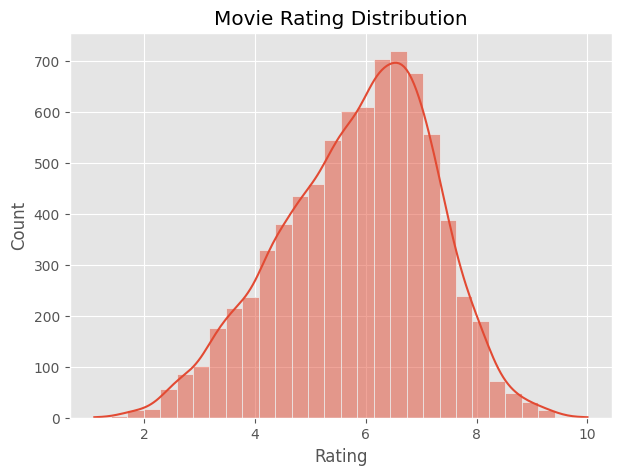

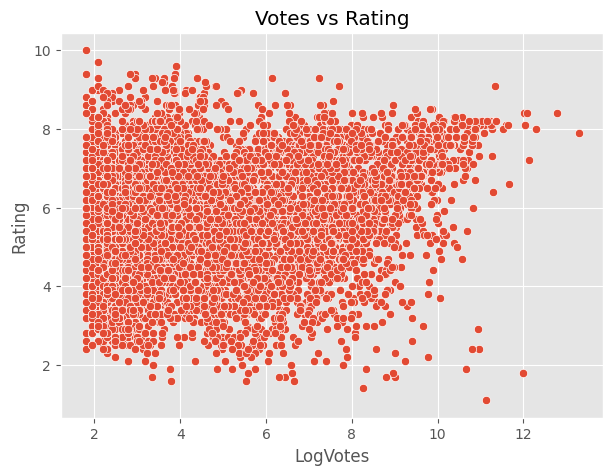

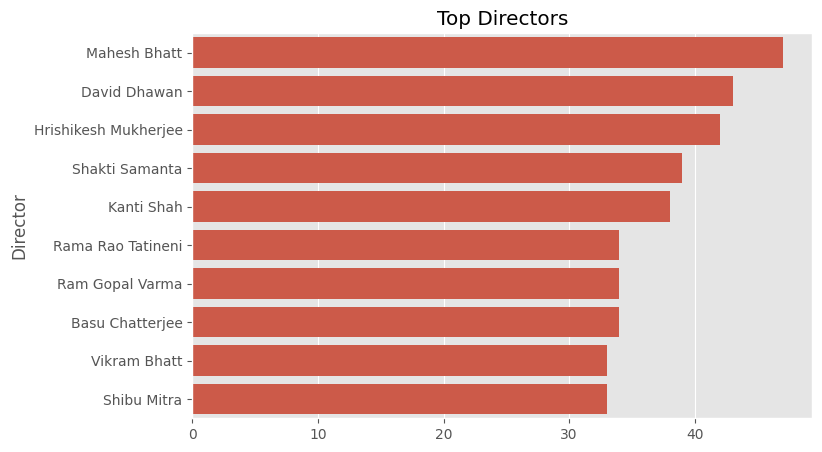


Top Directors (Minimum 5 Movies)
                   AvgRating       AvgVotes  MovieCount
Director                                               
Anand Patwardhan    8.287500     154.750000           8
Rajkumar Hirani     8.060000  139028.200000           5
Gulzar              7.521053     825.894737          19
Shoojit Sircar      7.500000   17179.285714           7
Guru Dutt           7.487500    1159.750000           8
Kidar Nath Sharma   7.466667      37.777778           9
Neeraj Pandey       7.460000   45869.800000           5
Anurag Kashyap      7.385714   15837.500000          14
Dibakar Banerjee    7.383333   13699.833333           6
Nishikant Kamat     7.360000   21796.800000           5


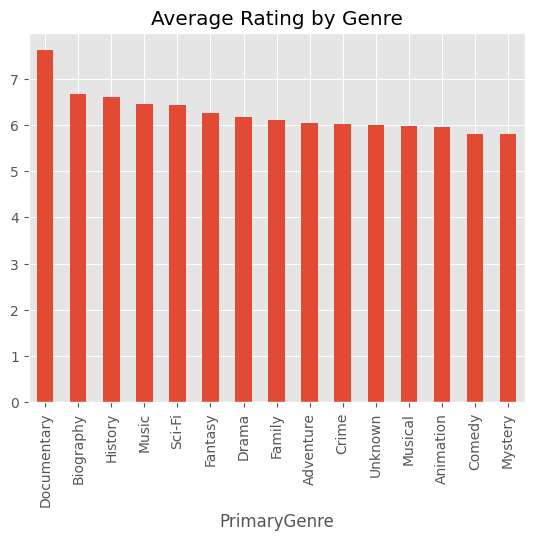

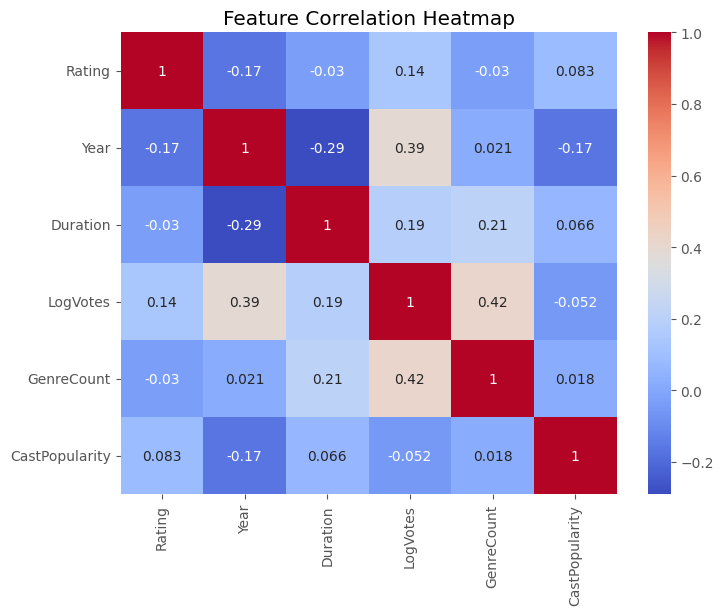


Top 10 Years by Average Rating
Year
1948    7.073684
1950    7.061290
1940    6.954545
1952    6.848148
1953    6.820690
1955    6.794737
1957    6.763462
1951    6.712500
1917    6.700000
2021    6.625641
Name: Rating, dtype: float64


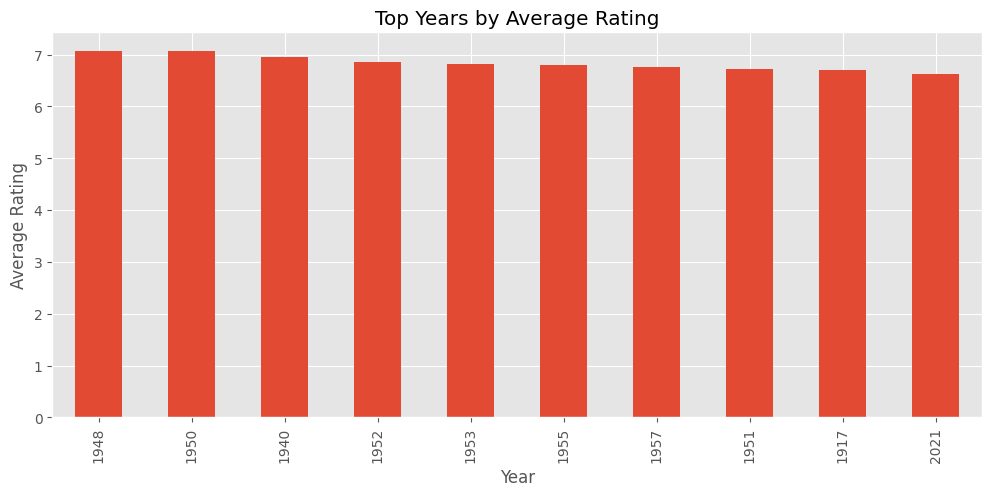


Top 10 Movies Overall
                      Name  Rating
8339       Love Qubool Hai    10.0
5410            Half Songs     9.7
2563                 Breed     9.6
5077          Gho Gho Rani     9.4
14222  The Reluctant Crime     9.4
6852                  June     9.4
11704             Ram-Path     9.4
9105                 Meher     9.3
5125           God of gods     9.3
11843              Refl3ct     9.3
       Year                     Name  Rating
8146   1917              Lanka Dahan     6.7
7203   1931                  Kalidas     6.2
14161  1931   The Light of the World     6.2
4171   1931                 Draupadi     5.3
2183   1932             Bharati Mata     6.1
6073   1932               Indrasabha     6.0
9035   1932          Maya Machhindra     5.8
2142   1932           Bhakta Prahlad     5.5
11464  1932              Radhe Shyam     3.8
845    1932  Alibaba Aur Chalis Chor     3.4
851    1933               Alif Laila     7.2
11138  1933             Puran Bhagat     6.5
4658   

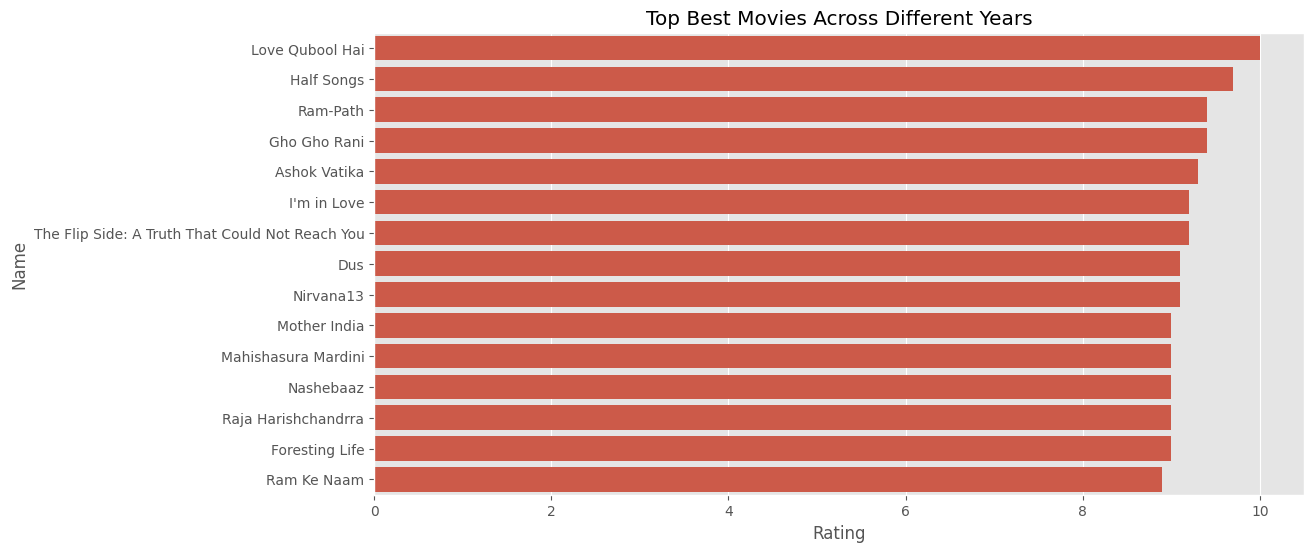

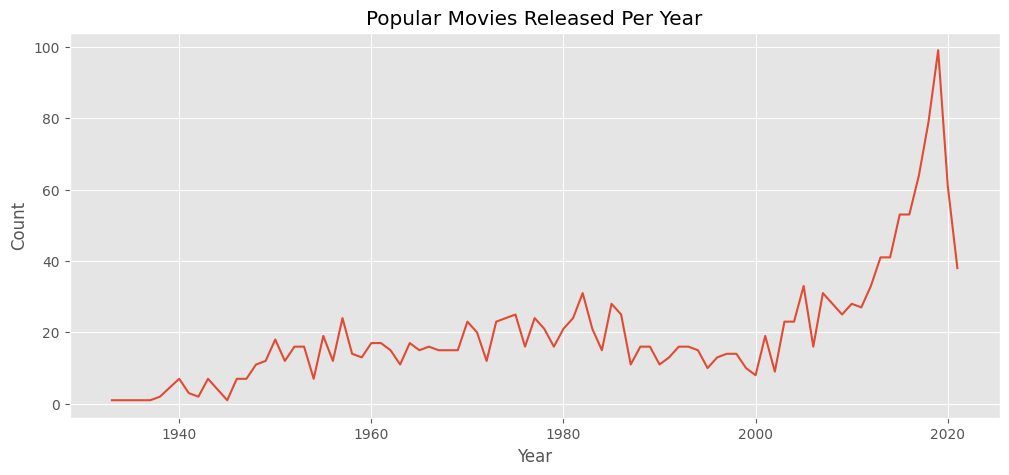


Most Voted Movies
                         Name   Votes  Rating
8219               Life of Pi  591417     7.9
75                   3 Idiots  357889     8.4
8233                     Lion  220526     8.0
4848                   Gandhi  220118     8.0
14038  The Darjeeling Limited  185127     7.2
8228      Like Stars on Earth  175810     8.4
10882                      PK  168150     8.1
3410                   Dangal  165074     8.4
11463                   Radhe  162455     1.8
3829              Dil Bechara  117377     6.6


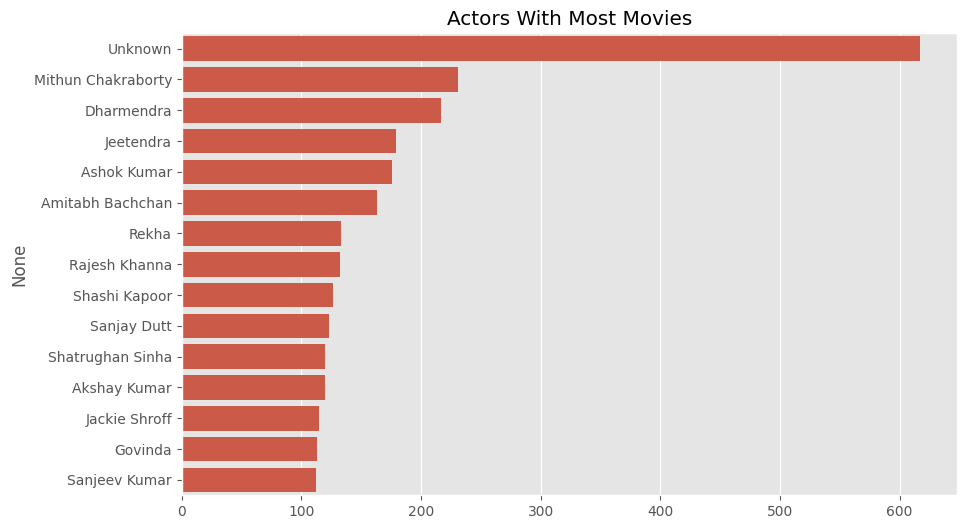

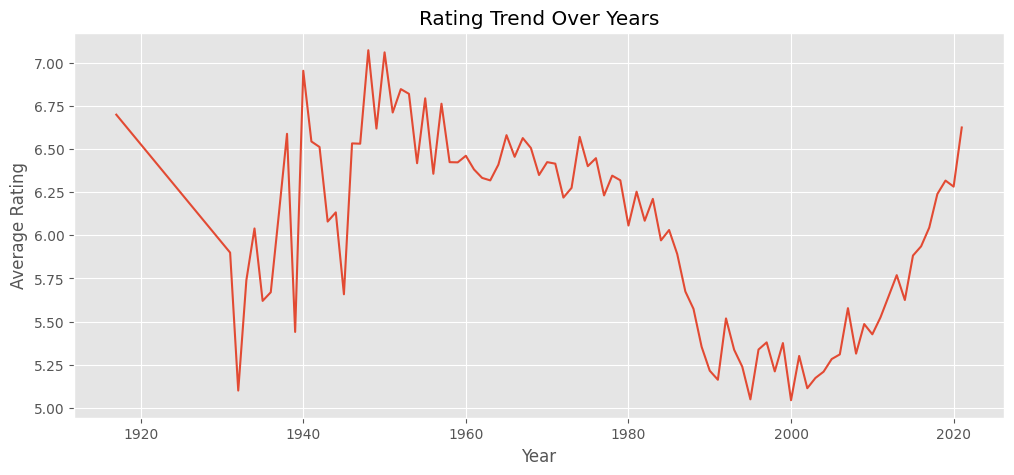

   Year  PredictedRating
0  2022         5.550841
1  2023         5.540683
2  2024         5.530526
3  2025         5.520368
4  2026         5.510210


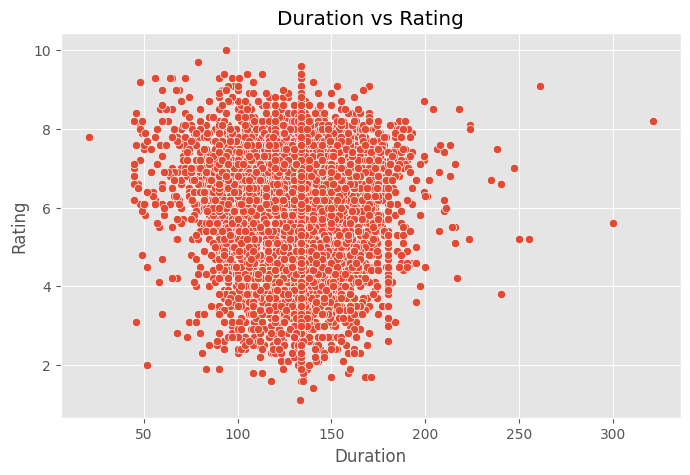


MODEL COMPARISON
Linear Regression    R² = 0.1991
Random Forest        R² = 0.3544
XGBoost              R² = 0.3767


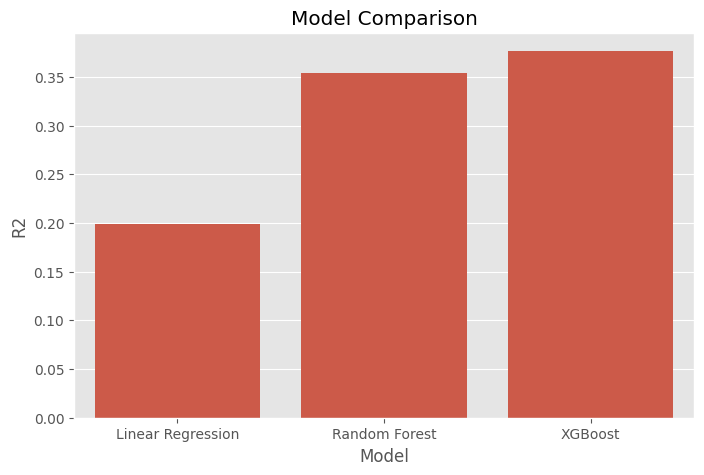


XGBOOST RESULTS
MAE : 0.8056
RMSE: 1.0738
R2  : 0.3797


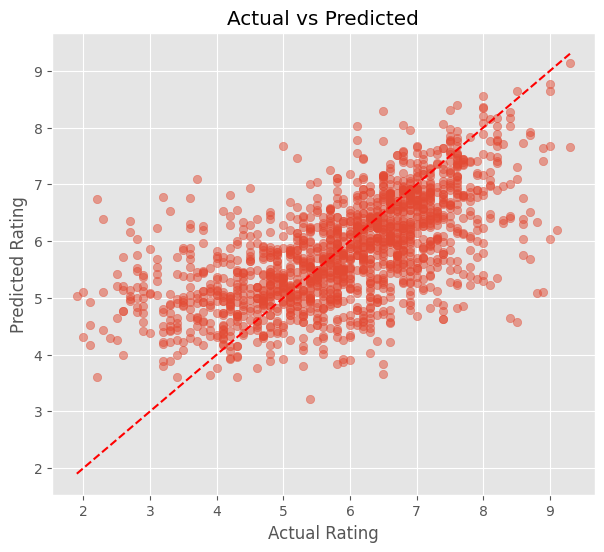

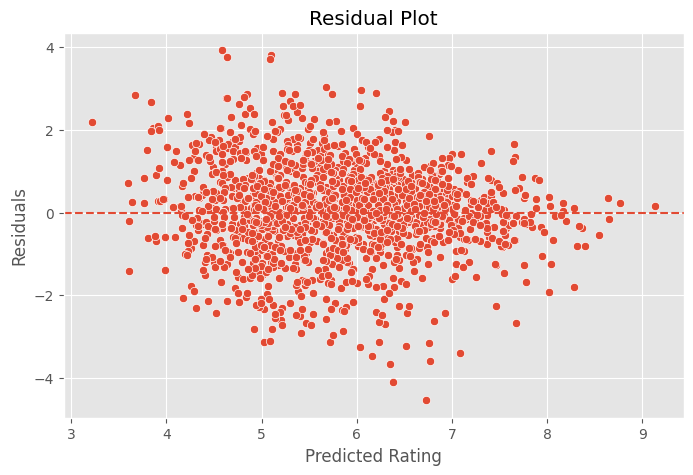

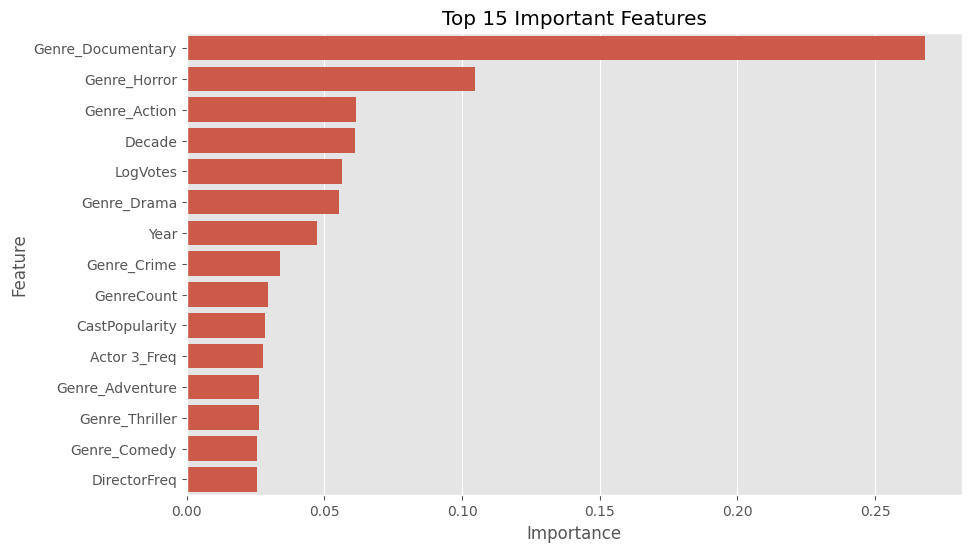


Sample Predictions
   Actual  Predicted
0     3.3   4.504098
1     5.3   3.791572
2     5.7   4.856139
3     7.2   4.826468
4     3.5   4.926540
5     7.2   5.510833
6     3.8   5.115625
7     6.9   7.019959
8     5.2   5.670534
9     7.4   5.778192

Model Saved Successfully


In [2]:

# CODSOFT DATA SCIENCE INTERNSHIP
# TASK 2 : MOVIE RATING PREDICTION WITH PYTHON

import warnings
warnings.filterwarnings("ignore")

import re
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")
np.random.seed(42)


# LOAD DATASET
df = pd.read_csv("IMDb Movies India.csv", encoding="latin-1")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


# DATA CLEANING
df = df[df["Rating"].notna()].copy()

df["Year"] = (
    df["Year"]
    .astype(str)
    .str.extract("(\d{4})")
)

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)


df["Duration"] = (
    df["Duration"]
    .astype(str)
    .str.extract("(\d+)")
)

df["Duration"] = pd.to_numeric(
    df["Duration"],
    errors="coerce"
)



df["Votes"] = (
    df["Votes"]
    .astype(str)
    .str.replace(",", "")
)

df["Votes"] = pd.to_numeric(
    df["Votes"],
    errors="coerce"
)



df["Year"].fillna(df["Year"].median(), inplace=True)
df["Duration"].fillna(df["Duration"].median(), inplace=True)
df["Votes"].fillna(df["Votes"].median(), inplace=True)


# FEATURE ENGINEERING


# Log Votes

df["LogVotes"] = np.log1p(df["Votes"])

# Decade

df["Decade"] = (
    df["Year"] // 10 * 10
)

# Genre Count

df["Genre"] = df["Genre"].fillna("Unknown")

df["GenreCount"] = df["Genre"].apply(
    lambda x: len(str(x).split(","))
)

# Primary Genre

df["PrimaryGenre"] = (
    df["Genre"]
    .str.split(",")
    .str[0]
    .str.strip()
)

# Frequency Encoding Function

def frequency_encode(series):
    freq = series.value_counts(normalize=True)
    return series.map(freq)

# Director Encoding

df["Director"] = df["Director"].fillna("Unknown")

df["DirectorFreq"] = frequency_encode(
    df["Director"]
)

# Actor Encoding

for col in ["Actor 1","Actor 2","Actor 3"]:

    df[col] = df[col].fillna("Unknown")

    df[col+"_Freq"] = frequency_encode(
        df[col]
    )

# Cast Popularity

df["CastPopularity"] = (
    df["Actor 1_Freq"]*0.5 +
    df["Actor 2_Freq"]*0.3 +
    df["Actor 3_Freq"]*0.2
)

# Top Genres

top_genres = (
    df["PrimaryGenre"]
    .value_counts()
    .head(10)
    .index
)

for genre in top_genres:

    df[f"Genre_{genre}"] = (
        df["PrimaryGenre"] == genre
    ).astype(int)


# EDA
plt.figure(figsize=(7,5))

sns.histplot(
    df["Rating"],
    bins=30,
    kde=True
)

plt.title("Movie Rating Distribution")
plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    x="LogVotes",
    y="Rating",
    data=df
)

plt.title("Votes vs Rating")
plt.show()

plt.figure(figsize=(8,5))

top_directors = (
    df["Director"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top Directors")
plt.show()

director_stats = (

    df.groupby("Director")
    .agg({

        "Rating":"mean",
        "Votes":"mean",
        "Name":"count"

    })

)

director_stats.columns = [

    "AvgRating",
    "AvgVotes",
    "MovieCount"

]

top_director_stats = (
    director_stats[
        director_stats["MovieCount"] >= 5
    ]
    .sort_values(
        "AvgRating",
        ascending=False
    )
)

print("\nTop Directors (Minimum 5 Movies)")
print(top_director_stats.head(10))
genre_rating = (

    df.groupby(
        "PrimaryGenre"
    )["Rating"]

    .mean()

    .sort_values(
        ascending=False
    )

)

genre_rating.head(15).plot(
    kind="bar"
)

plt.title(
    "Average Rating by Genre"
)

plt.show()
# Correlation Heatmap

corr_cols = [
    "Rating",
    "Year",
    "Duration",
    "LogVotes",
    "GenreCount",
    "CastPopularity"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()


year_rating = (
    df.groupby("Year")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Years by Average Rating")
print(year_rating.head(10))

plt.figure(figsize=(12,5))
year_rating.head(10).plot(kind="bar")
plt.title("Top Years by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Year")
plt.show()

top_movies = (
    df[["Name","Rating"]]
    .sort_values("Rating", ascending=False)
    .head(10)
)

print("\nTop 10 Movies Overall")
print(top_movies)


top_per_year = (
    df.sort_values(
        ["Year","Rating"],
        ascending=[True,False]
    )
    .groupby("Year")
    .head(10)
)

print(top_per_year[
    ["Year","Name","Rating"]
].head(50))

best_movie_per_year = (
    df.loc[
        df.groupby("Year")["Rating"]
        .idxmax()
    ]
)

print(
    best_movie_per_year[
        ["Year","Name","Rating"]
    ]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=best_movie_per_year.sort_values("Rating", ascending=False).head(15),
    x="Rating",
    y="Name"
)

plt.title("Top Best Movies Across Different Years")
plt.show()

popular_movies = df[df["Rating"] >= 7]

popular_year = (
    popular_movies
    .groupby("Year")
    .size()
)

plt.figure(figsize=(12,5))

popular_year.plot()

plt.title(
    "Popular Movies Released Per Year"
)

plt.ylabel("Count")

plt.show()

top_votes = (
    df[
        ["Name","Votes","Rating"]
    ]
    .sort_values(
        "Votes",
        ascending=False
    )
    .head(10)
)

print("\nMost Voted Movies")
print(top_votes)

actors = pd.concat([

    df["Actor 1"],
    df["Actor 2"],
    df["Actor 3"]

])

top_actors = actors.value_counts().head(15)

plt.figure(figsize=(10,6))

sns.barplot(

    x=top_actors.values,
    y=top_actors.index

)

plt.title(
    "Actors With Most Movies"
)

plt.show()

rating_trend = (

    df.groupby("Year")
    ["Rating"]

    .mean()

)

plt.figure(figsize=(12,5))

rating_trend.plot()

plt.title(
    "Rating Trend Over Years"
)

plt.ylabel(
    "Average Rating"
)

plt.show()


trend = (
    df.groupby("Year")
    ["Rating"]
    .mean()
    .reset_index()
)

lr = LinearRegression()

lr.fit(
    trend[["Year"]],
    trend["Rating"]
)

future_years = pd.DataFrame({

    "Year":
    range(
        int(trend["Year"].max())+1,
        int(trend["Year"].max())+6
    )

})

future_years["PredictedRating"] = (
    lr.predict(
        future_years[["Year"]]
    )
)

print(
    future_years
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Duration",
    y="Rating",
    data=df
)

plt.title("Duration vs Rating")

plt.show()


# FEATURE SELECTION


base_features = [

    "Year",
    "Duration",
    "LogVotes",
    "Decade",
    "GenreCount",

    "DirectorFreq",

    "Actor 1_Freq",
    "Actor 2_Freq",
    "Actor 3_Freq",

    "CastPopularity"
]

genre_features = [
    col
    for col in df.columns
    if col.startswith("Genre_")
]

features = base_features + genre_features

X = df[features]

y = df["Rating"]


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42
)


# MODELS
models = {

    "Linear Regression":

    Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]),

    "Random Forest":

    Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                random_state=42
            )
        )
    ]),

    "XGBoost":

    Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
        )
    ])
}


# Cross validation

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

print("\nMODEL COMPARISON")
print("="*60)

for name, model in models.items():

    scores = cross_val_score(

        model,
        X_train,
        y_train,

        cv=cv,

        scoring="r2"
    )

    print(
        f"{name:<20} "
        f"R² = {scores.mean():.4f}"
    )

    results.append(
        [name, scores.mean()]
    )


results_df = pd.DataFrame(
    results,
    columns=["Model", "R2"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2",
    data=results_df
)

plt.title("Model Comparison")

plt.show()

# Best model

best_model = models["XGBoost"]

best_model.fit(
    X_train,
    y_train
)

predictions = best_model.predict(
    X_test
)


# EVALUATION


mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\n" + "="*60)
print("XGBOOST RESULTS")
print("="*60)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2  :", round(r2,4))


# Actual vs predicted


plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted")
plt.show()

residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")

plt.show()


# Feature importance

xgb_model = best_model.named_steps["model"]

importance = pd.DataFrame({

    "Feature": features,

    "Importance":
    xgb_model.feature_importances_

})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",
    y="Feature",

    data=importance
)

plt.title(
    "Top 15 Important Features"
)

plt.show()


# Sample prediction
sample = pd.DataFrame({

    "Actual": y_test.values[:10],

    "Predicted":
    predictions[:10]
})

print("\nSample Predictions")
print(sample)


# Save model
with open(
    "movie_rating_model.pkl",
    "wb"
) as f:

    pickle.dump(
        best_model,
        f
    )

print("\nModel Saved Successfully")